In [82]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns   
import datetime as dt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
     

In [83]:
df = pd.read_csv('C:\\Users\\aviji\\Desktop\\capstone_project_1\\olist_orders_dataset.csv')

In [84]:
df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [85]:
df.describe()
df.isnull().sum()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


mere questions ye hai ab tu bata ki ye kitne sahi hai and insab mein se hum kya kya puche 
1. order purchase se lekar aprove ka average time kitna tha and agar koi bhaut zayada tha toh it can be an outliar 
2. order_div_date and orderd_div_customer date mein space kitne khali hai 
3. order_estimated_div_date and orderd_div_customer kitna aya hai agar on an avg bahut zayda hai toh bhai phir dikkat hai humare prediction mein hi 
4. order_purchase_date mein purchase huye par aprove nahi ho paaye wo aakhir konse products hai ? 
5. order_delivered_carrier_date and order_delivered_customer_date inmein aakhir kya diffrence hai i mean ye aakhir kyu order_delivered_customer_date mein utne columns nahi hai jo carrrier date mein hai kya cheeze carrier ke dwara lejayi gayi par customer tak nahi pahuchi 
6. and order approve hoke caarier ke paas nahi gaye kyu ?

In [86]:
display(df)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [87]:
date_cols = [
    
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]



for cols in date_cols:
    df[cols] = pd.to_datetime(df[cols],errors = 'coerce')

In [88]:
# Q1: PURCHASE → APPROVAL TIME

# 1) Purchase aur Approval ke beech actual time difference nikalo
df['purchase_to_approve'] = (df['order_approved_at'] - df['order_purchase_timestamp']).dt.total_seconds() / 3600
# ↑ dono datetimes ka difference nikala → seconds → hours me convert kiya

# 2) Kuch orders approve hi nahi hue, isliye NaN aa jayega — unko ignore karke summary lo
summary = df['purchase_to_approve'].describe()
# ↑ approve time distribution ka quick summary (mean, std, min, max, percentile)

print(summary)


count    99281.000000
mean        10.419094
std         26.038004
min          0.000000
25%          0.215000
50%          0.343333
75%         14.580833
max       4509.180556
Name: purchase_to_approve, dtype: float64


In [89]:
# Find slow approvals (> 24 hours)
slow = df[df['purchase_to_approve'] > 24]

# Find impossible approvals (< 0)
impossible = df[df['purchase_to_approve'] < 0]

print("Slow approvals:", len(slow))
print("Impossible approvals:", len(impossible))


Slow approvals: 17419
Impossible approvals: 0


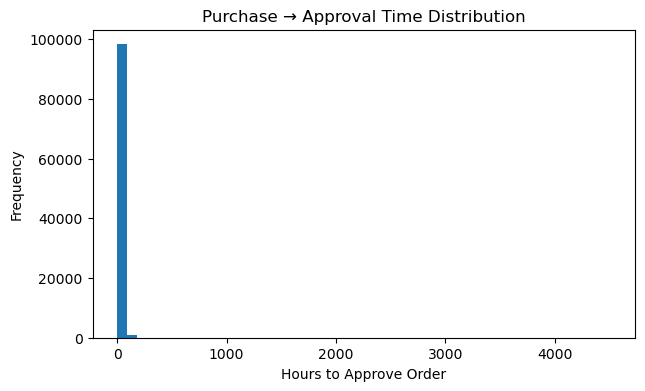

In [90]:
import matplotlib.pyplot as plt

# 1) NaN hatake sirf valid durations lo
vals = df['purchase_to_approve'].dropna()

# 2) Basic histogram plot
plt.figure(figsize=(7,4))
plt.hist(vals, bins=50)
plt.xlabel("Hours to Approve Order")
plt.ylabel("Frequency")
plt.title("Purchase → Approval Time Distribution")
plt.show()


In [91]:
# DIAG 1: percentiles and counts (very small, self-contained)
vals = df['purchase_to_approve'].dropna()                # valid durations (hours)
print("count:", len(vals))                                # how many valid values
print("negatives (impossible):", (vals < 0).sum())        # impossible timestamps
# show robust stats (median/IQR) instead of mean
print("median (hrs):", vals.median())
print("mean (hrs):", vals.mean())
print("std (hrs):", vals.std())
print("percentiles (hrs):")
print(vals.quantile([0.5, 0.75, 0.90, 0.95, 0.99, 0.999]).to_string())


count: 99281
negatives (impossible): 0
median (hrs): 0.3433333333333333
mean (hrs): 10.419094301919692
std (hrs): 26.038003638429693
percentiles (hrs):
0.500      0.343333
0.750     14.580833
0.900     34.659722
0.950     48.463611
0.990     90.166500
0.999    154.338544


In [92]:
# DIAG 2: list top offenders and sample their raw date columns for context
top = df.sort_values('purchase_to_approve', ascending=False).head(40)   # top 40 extremes
# show only a few useful columns so you can inspect what's wrong
print(top[['order_id','order_purchase_timestamp','order_approved_at','purchase_to_approve', 'order_delivered_customer_date']].to_string(index=False))
# also print count of orders beyond practical thresholds
print(" >24 hrs:", (vals > 24).sum(), " >72 hrs:", (vals > 72).sum(), " >168 hrs(7d):", (vals > 168).sum())


                        order_id order_purchase_timestamp   order_approved_at  purchase_to_approve order_delivered_customer_date
1612081119e8f23745698ad3367cc14b      2016-10-05 18:06:48 2017-04-11 15:17:38          4509.180556                           NaT
2e5dc86c8c4aa663549caf5e31de840d      2017-02-03 00:04:49 2017-04-04 10:56:48          1450.866389                           NaT
2e7a8482f6fb09756ca50c10d7bfc047      2016-09-04 21:15:19 2016-10-07 13:18:03           784.045556                           NaT
e5fa5a7210941f7d56d0208e4e071d35      2016-09-05 00:15:34 2016-10-07 13:17:15           781.028056                           NaT
0a5c74ccc786ced7903270de9d6c170a      2018-01-18 23:14:36 2018-02-20 12:05:54           780.855000                           NaT
0a93b40850d3f4becf2f276666e01340      2018-01-20 14:24:50 2018-02-20 11:51:27           741.443611           2018-03-02 22:37:49
f7923db0430587601c2aef15ec4b8af4      2018-01-20 17:38:58 2018-02-20 12:05:54           738.44888

In [93]:
df['flag_impossible'] = df['purchase_to_approve'] < 0
df['flag_outlier'] = df['purchase_to_approve'] > df['purchase_to_approve'].quantile(0.99)
df['flag_very_slow'] = df['purchase_to_approve'] > 48   # 48 hours threshold
df['flag_never_delivered'] = df['order_delivered_customer_date'].isna()


In [94]:
display(df.head())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_to_approve,flag_impossible,flag_outlier,flag_very_slow,flag_never_delivered
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,0.178333,False,False,False,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,30.713889,False,False,False,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,0.276111,False,False,False,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,0.298056,False,False,False,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1.030556,False,False,False,False


In [95]:
# 1) calculate last-mile delivery time in DAYS
df['carrier_to_customer_days'] = (
    df['order_delivered_customer_date'] - df['order_delivered_carrier_date']
).dt.total_seconds() / 86400
# ↑ dono datetimes ka difference लिया → seconds → days में convert किया

# 2) negative values = impossible (delivered before carrier pickup)
df['flag_carrier_negative'] = df['carrier_to_customer_days'] < 0


In [96]:
vals = df['carrier_to_customer_days'].dropna()

print("Median days:", vals.median())         # real “typical” last-mile time
print("Mean days:", vals.mean())             # ignore later if outliers skew it
print("Percentiles:")
print(vals.quantile([0.5,0.75,0.9,0.95,0.99]).to_string())
print("Negative cases:", (vals < 0).sum())   # broken timestamps


Median days: 7.099768518518519
Mean days: 9.330546923017861
Percentiles:
0.50     7.099769
0.75    12.029115
0.90    18.899972
0.95    24.209712
0.99    40.983047
Negative cases: 23


In [97]:
# orders delivered after extremely long last-mile delay (>20 days)
slow_last_mile = df[df['carrier_to_customer_days'] > 20]

print("Very slow last-mile deliveries:", len(slow_last_mile))
print(slow_last_mile[['order_id','carrier_to_customer_days']])


Very slow last-mile deliveries: 8402
                               order_id  carrier_to_customer_days
25     fbf9ac61453ac646ce8ad9783d7d0af6                 22.985093
29     ecab90c9933c58908d3d6add7c6f5ae3                 29.041944
35     8563039e855156e48fccee4d611a3196                 27.080197
89     20e0101b20700188cadb288126949685                 21.858264
97     6a0a8bfbbe700284feb0845d95e0867f                 31.252373
...                                 ...                       ...
99397  0fa1fab1d7c1211c824596ed5e111e3c                 22.022523
99423  38e9133ce29f6bbe35aed9c3863dce01                 35.001586
99432  cfa78b997e329a5295b4ee6972c02979                 36.805428
99437  63943bddc261676b46f01ca7ac2f7bd8                 20.760579
99438  83c1379a015df1e13d02aae0204711ab                 23.605451

[8402 rows x 2 columns]


In [98]:
# 1) Calculate last-mile duration (if not already done)
df['carrier_to_customer_days'] = (
    df['order_delivered_customer_date'] - df['order_delivered_carrier_date']
).dt.total_seconds() / 86400
# ↑ difference liya → seconds → days

# 2) Flag negative (impossible) durations
df['flag_negative_lastmile'] = df['carrier_to_customer_days'] < 0
# ↑ negative means delivered before carrier pickup → data error

# 3) Remove negative rows COMPLETELY from the dataset
df = df[df['carrier_to_customer_days'] >= 0].reset_index(drop=True)
# ↑ sirf woh rows rakhi jisme delivery time >= 0 hai

# 4) Flag very slow deliveries (> 20 days)
df['very_slow_delivery'] = df['carrier_to_customer_days'] > 20
# ↑ True = delivery took more than 20 days

# 5) Quick check counts
print("Negative removed:", df['flag_negative_lastmile'].sum())
print("Very slow deliveries:", df['very_slow_delivery'].sum())

print("Negative cases:", (vals < 0).sum())


Negative removed: 0
Very slow deliveries: 8402
Negative cases: 23


In [99]:
df['carrier_to_customer_days'] = (
    df['order_delivered_customer_date'] - df['order_delivered_carrier_date']
).dt.total_seconds() / 86400
# ↑ difference liya → seconds → days

# 2) Flag negative (impossible) durations
df['flag_negative_lastmile'] = df['carrier_to_customer_days'] < 0
# ↑ negative means delivered before carrier pickup → data error

# 3) Remove negative rows COMPLETELY from the dataset
df = df[df['carrier_to_customer_days'] >= 0].reset_index(drop=True)
# ↑ sirf woh rows rakhi jisme delivery time >= 0 hai

# 4) Flag very slow deliveries (> 20 days)

# ↑ True = delivery took more than 20 days

# 5) Quick check counts
print("Negative removed:", df['flag_negative_lastmile'].sum())
print("Very slow deliveries:", df['very_slow_delivery'].sum())

print("Negative cases:", (df['carrier_to_customer_days'] < 0).sum())

Negative removed: 0
Very slow deliveries: 8402
Negative cases: 0


In [100]:
# 1) Delivery delay in DAYS: +ve = late, -ve = early
df['delivery_delay_days'] = (
    df['order_delivered_customer_date'] - df['order_estimated_delivery_date']
).dt.total_seconds() / 86400
# ↑ estimated date minus actual delivery date difference, seconds → days


In [101]:
vals = df['delivery_delay_days'].dropna()   # valid delays only

print("Median delay:", vals.median())       # typical behavior
print("Mean delay:", vals.mean())
print("\nPercentiles:")
print(vals.quantile([0.5,0.75,0.9,0.95,0.99]).to_string())

print("\nEarly (delivered BEFORE estimate):", (vals < 0).sum())
print("Late  (delivered AFTER estimate):", (vals > 0).sum())


Median delay: -11.944936342592593
Mean delay: -11.176303530032593

Percentiles:
0.50   -11.944936
0.75    -6.388704
0.90    -1.137448
0.95     3.819030
0.99    18.940294

Early (delivered BEFORE estimate): 88626
Late  (delivered AFTER estimate): 7826


In [102]:
# 2+ days late = minor late
df['late_2days'] = df['delivery_delay_days'] > 2

# 5+ days late = serious delay
df['late_5days'] = df['delivery_delay_days'] > 5

# 10+ days late = extreme delay
df['late_10days'] = df['delivery_delay_days'] > 10

# Quick counts
print("Late >2 days:", df['late_2days'].sum())
print("Late >5 days:", df['late_5days'].sum())
print("Late >10 days:", df['late_10days'].sum())


Late >2 days: 5709
Late >5 days: 4211
Late >10 days: 2300


In [104]:
# 1) Flag unapproved orders (approved_at is NaT)
df['not_approved'] = df['order_approved_at'].isna()
# ↑ True = order purchase hua but approval nahi mila


In [105]:
# how many?
print("Total unapproved orders:", df['not_approved'].sum())

# % of all orders
print("Percentage:", round(df['not_approved'].sum() / len(df) * 100, 2), "%")


Total unapproved orders: 14
Percentage: 0.01 %


In [107]:
df.to_csv('cleaned_orders_dataset.csv', index=False)

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96452 entries, 0 to 96451
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96452 non-null  object        
 1   customer_id                    96452 non-null  object        
 2   order_status                   96452 non-null  object        
 3   order_purchase_timestamp       96452 non-null  datetime64[ns]
 4   order_approved_at              96438 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96452 non-null  datetime64[ns]
 6   order_delivered_customer_date  96452 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96452 non-null  datetime64[ns]
 8   purchase_to_approve            96438 non-null  float64       
 9   flag_impossible                96452 non-null  bool          
 10  flag_outlier                   96452 non-null  bool          
 11  flag_very_slow 